# 07 — Perseus works: Wikidata type distributions

Top-20 values for three Wikidata fields on the Perseus works table:
`instance_of`, `genre`, `form_of_creative_work`. Cells are comma-separated
so values are split and exploded before counting.

**Source**: `data/processed_data/perseus_works_wikidata.tsv`.

*Follows `notebook_rule.md`.*

## 1. Setup — imports, style, paths

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

INPUT_TSV = Path('../data/clean/perseus/perseus_works_wikidata.tsv')

In [2]:
# Consistent styling — matches the other analysis notebooks.
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'Helvetica',
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'axes.labelsize': 9,
    'axes.titlesize': 11,
    'legend.frameon': False,
})

BAR = 'steelblue'

## 2. Load data

In [3]:
df = pd.read_csv(INPUT_TSV, sep='\t')
print(f'Total works (rows): {len(df):,}')
assert df['file_id'].is_unique, 'file_id must be unique'
df[['file_id', 'perseus_author', 'perseus_title',
    'instance_of', 'genre', 'form_of_creative_work']].head()

Total works (rows): 1,096


,file_id,perseus_author,perseus_title,instance_of,genre,form_of_creative_work
0,tlg0003.tlg001.perseus-eng6,Thucydides,History of the Peloponnesian War,historical non-fiction work,historiography,NaN
1,tlg0003.tlg001.1st1K-eng1,Thucydides,The Peloponnesian War,historical non-fiction work,historiography,NaN
2,tlg0003.tlg001.perseus-eng4,Thucydides,The History of the Grecian War,"version, edition or translation",NaN,NaN
3,tlg0003.tlg001.1st1K-ger1,Thucydides,Vier Staatsreden aus Thucydides,"version, edition or translation",NaN,NaN
4,tlg0003.tlg001.perseus-grc2,Thucydides,Ἱστορίαι,NaN,NaN,NaN


## 3. Preprocessing — explode comma-separated Wikidata fields

In [4]:
def exploded_counts(column, n=20):
    s = (df[column].dropna().astype(str)
                   .str.split(',').explode().str.strip())
    s = s[s != '']
    return s.value_counts().head(n)


instance_counts = exploded_counts('instance_of')
genre_counts    = exploded_counts('genre')
form_counts     = exploded_counts('form_of_creative_work')

print('instance_of   — unique values:', df['instance_of'].nunique())
print('genre         — unique values:', df['genre'].nunique())
print('form_of_creat — unique values:', df['form_of_creative_work'].nunique())

pd.DataFrame({
    'instance_of top-5':   instance_counts.head(5).index.tolist()
                            + [''] * max(0, 5 - len(instance_counts)),
    'genre top-5':         genre_counts.head(5).index.tolist()
                            + [''] * max(0, 5 - len(genre_counts)),
    'form_of_c.w. top-5':  form_counts.head(5).index.tolist()
                            + [''] * max(0, 5 - len(form_counts)),
})

instance_of   — unique values: 34
genre         — unique values: 43
form_of_creat — unique values: 11


,instance_of top-5,genre top-5,form_of_c.w. top-5
0,literary work,biography,play
1,oration,dialogue,prose
2,written work,Greek tragedy,novel
3,dramatic work,Socratic dialogue,poetry collection
4,version,treatise,poem


## 4. Plotting helper

In [5]:
def hbar_counts(counts, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.barh(range(len(counts)), counts.values, color=BAR,
            edgecolor='white', height=0.72)
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(counts.values):
        ax.text(v + max(counts.values) * 0.005, i, str(int(v)),
                va='center', fontsize=8)
    fig.tight_layout()
    return fig, ax

## 5. Figures

### Figure 1: Top 20 — Instance Of

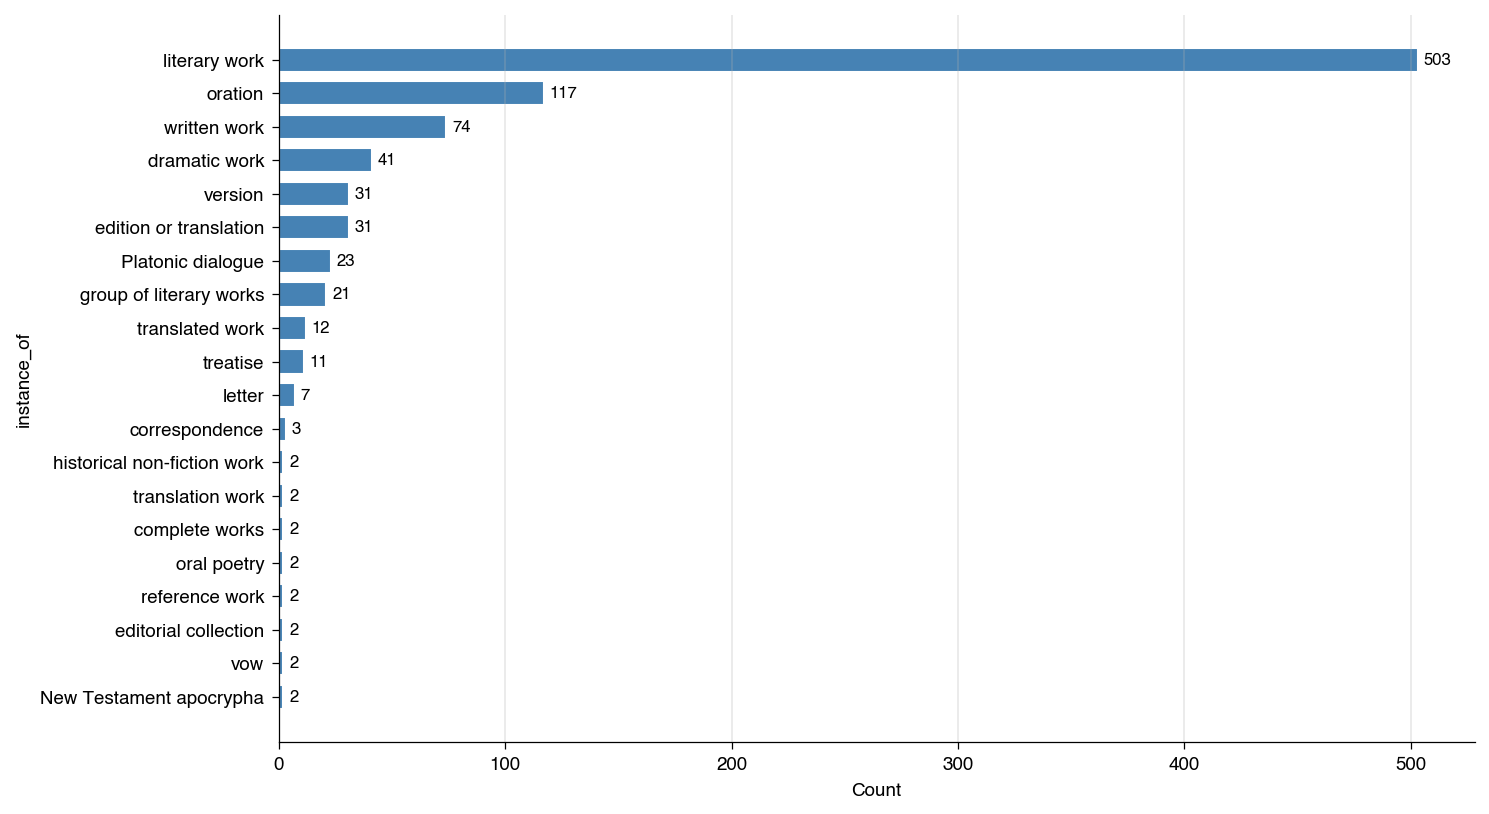

In [6]:
hbar_counts(instance_counts, xlabel='Count', ylabel='instance_of');

### Figure 2: Top 20 — Genre

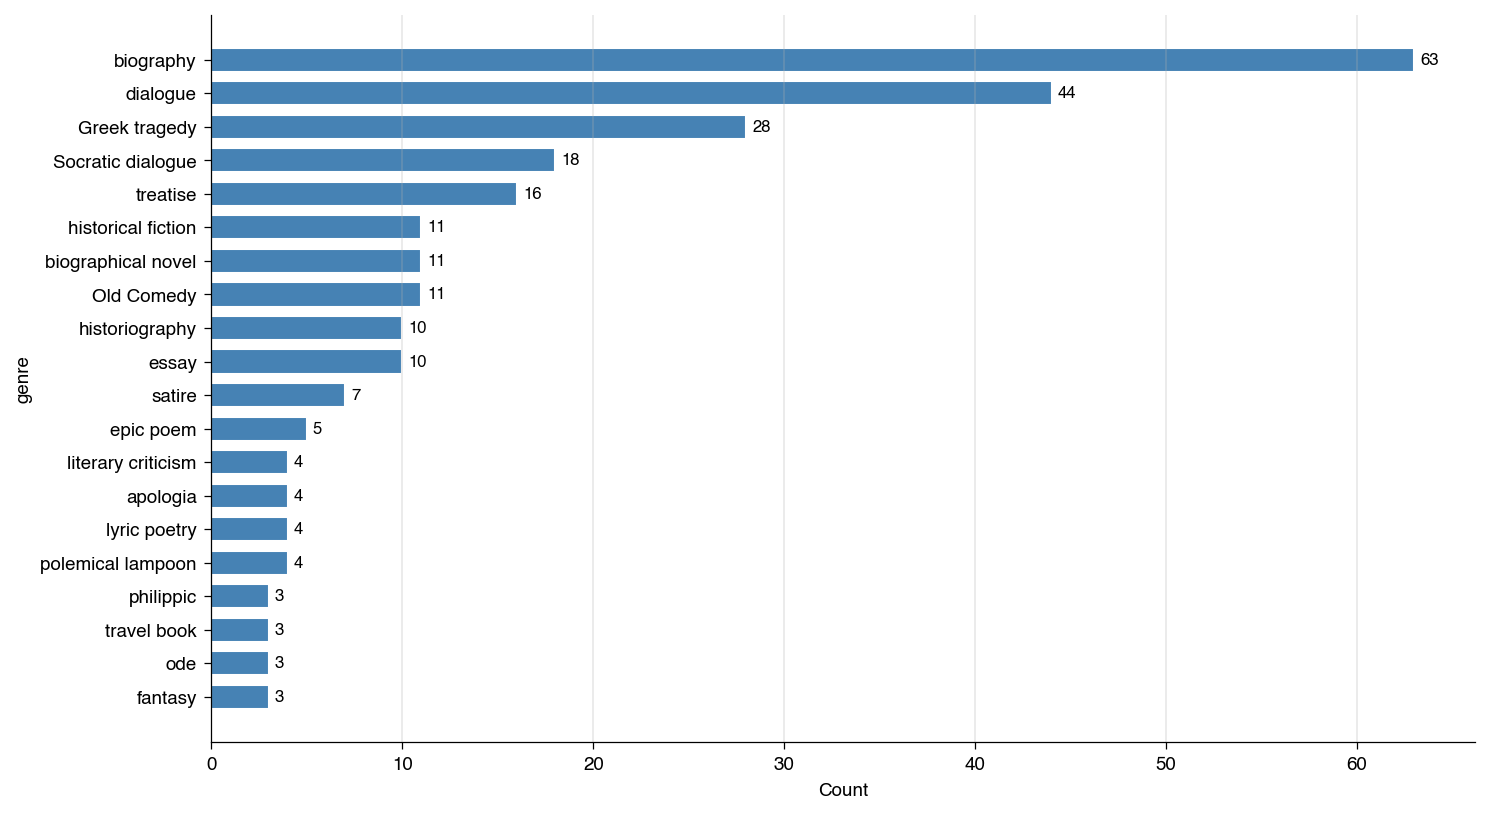

In [7]:
hbar_counts(genre_counts, xlabel='Count', ylabel='genre');

### Figure 3: Top 20 — Form of creative work

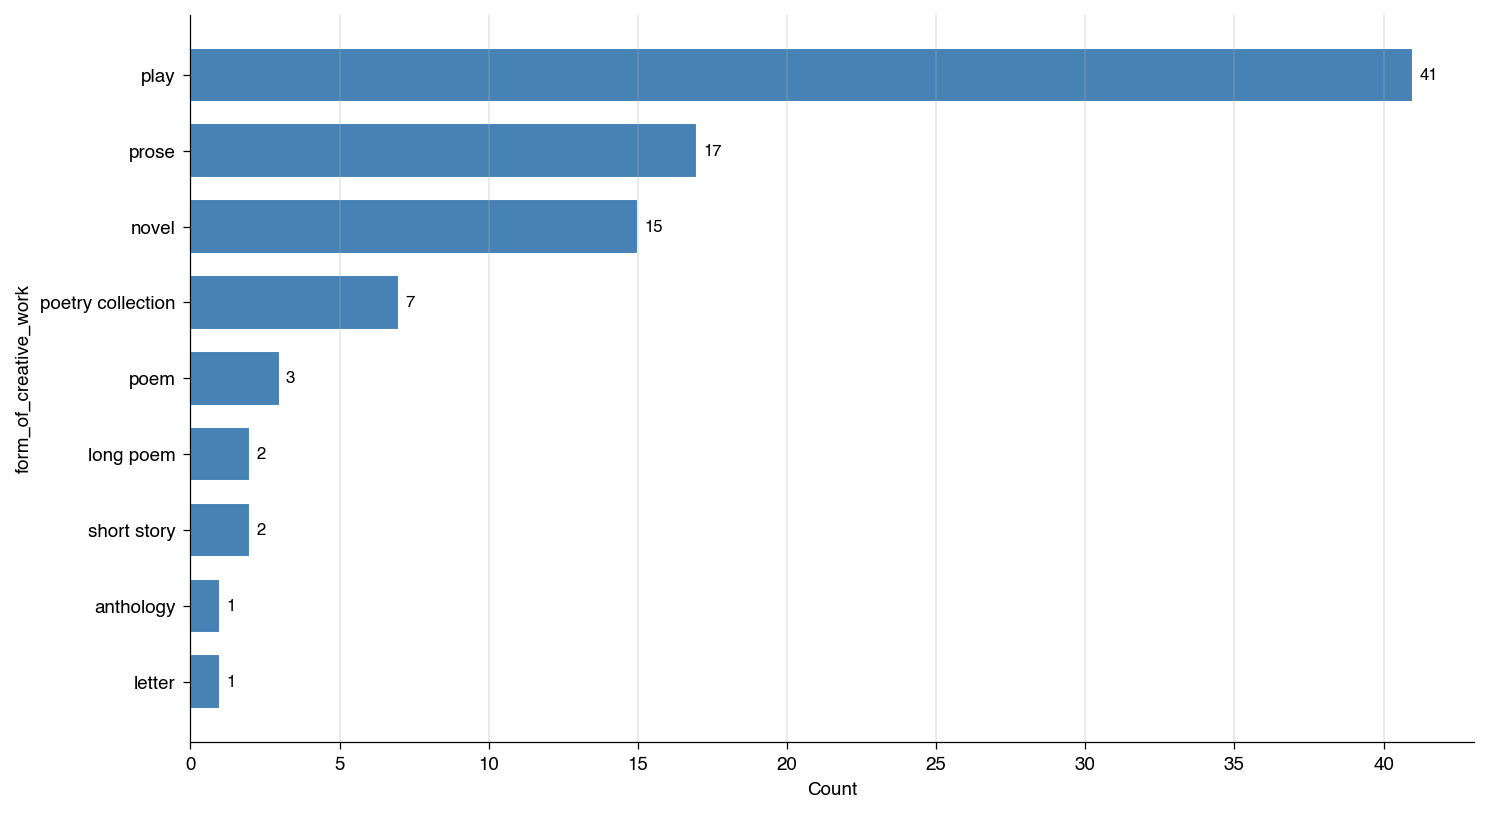

In [8]:
hbar_counts(form_counts, xlabel='Count', ylabel='form_of_creative_work');